# Analisis de Turismo Receptivo en Peru (2018-2023)
Estudio de flujos turisticos internacionales, estacionalidad y recuperacion post-COVID.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [2]:
np.random.seed(123)

paises = {
    'Chile': 0.30, 'Estados Unidos': 0.15, 'Ecuador': 0.08,
    'Colombia': 0.07, 'Argentina': 0.06, 'Brasil': 0.05,
    'Espana': 0.04, 'Otros': 0.25
}

total_anual = {
    2018: 4_400_000,
    2019: 4_750_000,
    2020: 800_000,
    2021: 1_500_000,
    2022: 2_800_000,
    2023: 3_600_000
}

estacionalidad = {
    1: 1.05, 2: 0.90, 3: 0.88, 4: 0.85, 5: 0.82,
    6: 0.92, 7: 1.25, 8: 1.20, 9: 1.00, 10: 1.02,
    11: 1.05, 12: 1.10
}

fechas = pd.date_range('2018-01', '2023-12', freq='MS')

In [3]:
covid_mensual_2020 = {
    1: 0.95, 2: 0.85, 3: 0.30, 4: 0.05, 5: 0.05,
    6: 0.08, 7: 0.15, 8: 0.30, 9: 0.45, 10: 0.55,
    11: 0.60, 12: 0.65
}

registros = []
for fecha in fechas:
    anio, mes = fecha.year, fecha.month
    base_mensual = total_anual[anio] / 12
    ajuste_est = estacionalidad[mes]

    if anio == 2020:
        ajuste_covid = covid_mensual_2020[mes]
    else:
        ajuste_covid = 1.0

    for pais, peso in paises.items():
        variacion_pais = 1.0
        if anio >= 2021 and pais == 'Chile':
            variacion_pais = 1.15
        elif anio >= 2021 and pais == 'Estados Unidos':
            variacion_pais = 0.85

        llegadas = base_mensual * peso * ajuste_est * ajuste_covid * variacion_pais
        llegadas *= (1 + np.random.normal(0, 0.05))
        registros.append({
            'fecha': fecha, 'anio': anio, 'mes': mes,
            'pais': pais, 'llegadas': max(int(llegadas), 0)
        })

df = pd.DataFrame(registros)
print(f'Registros: {len(df):,} | Paises: {df.pais.nunique()} | Rango: {df.anio.min()}-{df.anio.max()}')

Registros: 576 | Paises: 8 | Rango: 2018-2023


## 1. Llegadas mensuales con periodo COVID

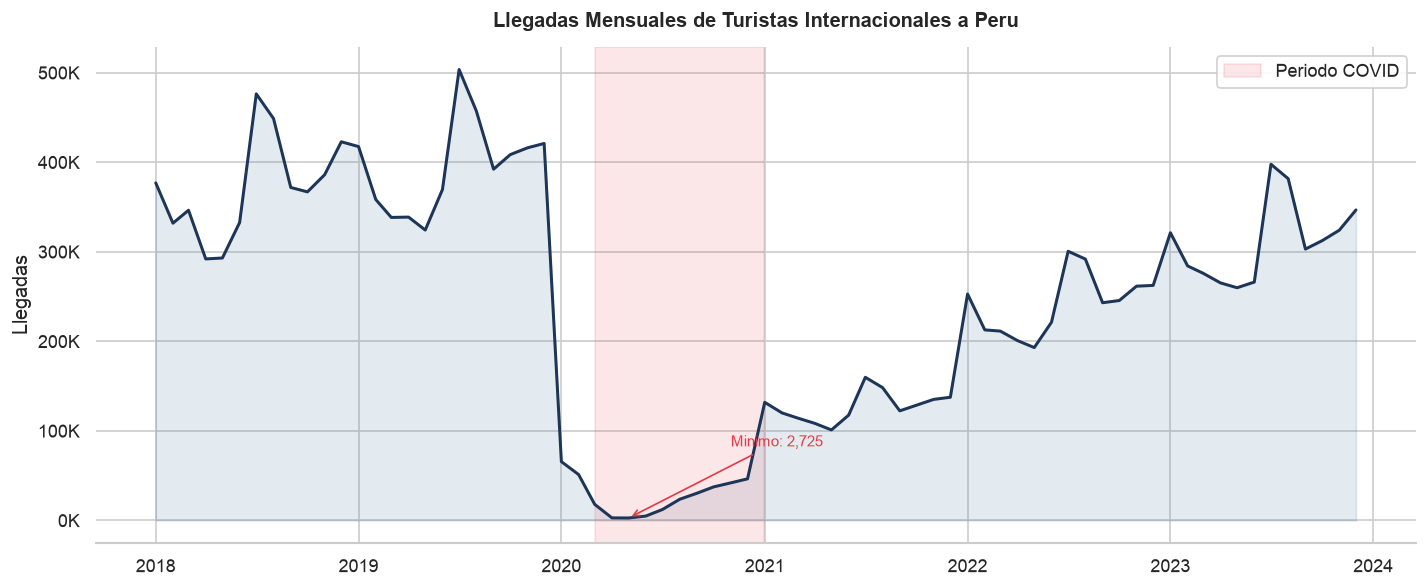

In [4]:
llegadas_mes = df.groupby('fecha')['llegadas'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(llegadas_mes['fecha'], llegadas_mes['llegadas'],
        color='#1d3557', lw=1.8, zorder=3)
ax.fill_between(llegadas_mes['fecha'], llegadas_mes['llegadas'],
                alpha=0.15, color='#457b9d')

inicio_covid = pd.Timestamp('2020-03-01')
fin_covid = pd.Timestamp('2020-12-31')
ax.axvspan(inicio_covid, fin_covid, alpha=0.12, color='#e63946', label='Periodo COVID')

min_idx = llegadas_mes.loc[
    (llegadas_mes['fecha'] >= '2020-01-01') & (llegadas_mes['fecha'] <= '2020-12-31'),
    'llegadas'
].idxmin()
min_fecha = llegadas_mes.loc[min_idx, 'fecha']
min_val = llegadas_mes.loc[min_idx, 'llegadas']
ax.annotate(f'Minimo: {min_val:,.0f}', xy=(min_fecha, min_val),
            xytext=(min_fecha + pd.DateOffset(months=6), min_val + 80000),
            arrowprops=dict(arrowstyle='->', color='#e63946'),
            fontsize=9, color='#e63946')

ax.set_title('Llegadas Mensuales de Turistas Internacionales a Peru', fontweight='bold', pad=12)
ax.set_ylabel('Llegadas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(loc='upper right', framealpha=0.9)
sns.despine(left=True)
plt.tight_layout()
plt.show()

## 2. Participacion de mercado por pais emisor

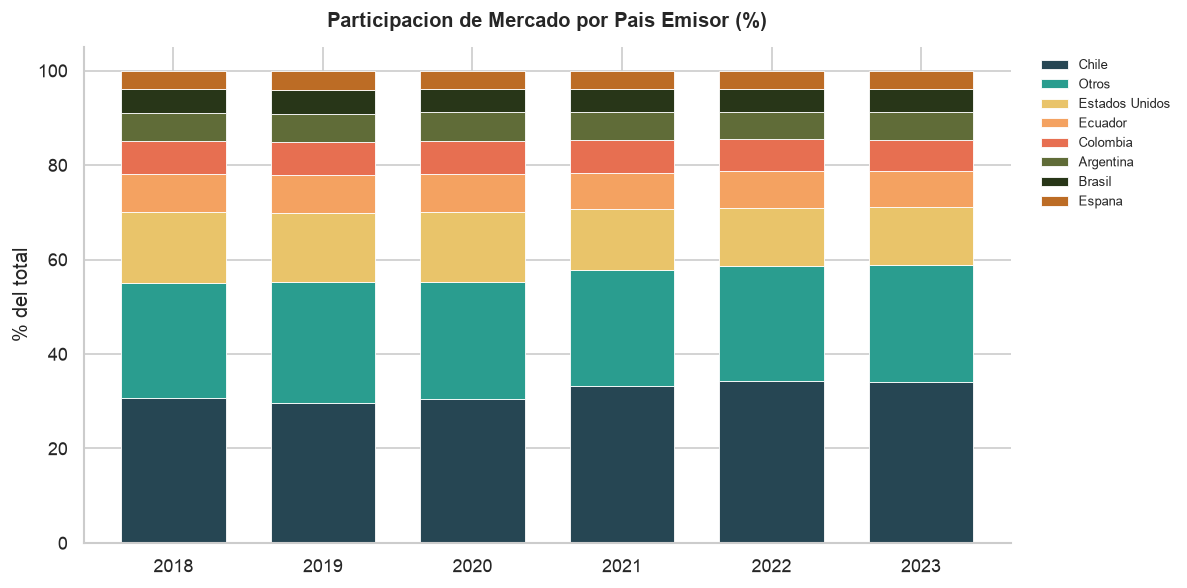

In [5]:
share_anual = df.pivot_table(index='anio', columns='pais', values='llegadas', aggfunc='sum')
share_pct = share_anual.div(share_anual.sum(axis=1), axis=0) * 100

orden_paises = share_pct.iloc[-1].sort_values(ascending=False).index.tolist()
share_pct = share_pct[orden_paises]

paleta = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261',
          '#e76f51', '#606c38', '#283618', '#bc6c25']

fig, ax = plt.subplots(figsize=(10, 5))
share_pct.plot(kind='bar', stacked=True, ax=ax, color=paleta[:len(orden_paises)],
               width=0.7, edgecolor='white', linewidth=0.5)

ax.set_title('Participacion de Mercado por Pais Emisor (%)', fontweight='bold', pad=12)
ax.set_ylabel('% del total')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=False)
ax.set_ylim(0, 105)
sns.despine()
plt.tight_layout()
plt.show()

## 3. Indice de estacionalidad mensual (grafico polar)

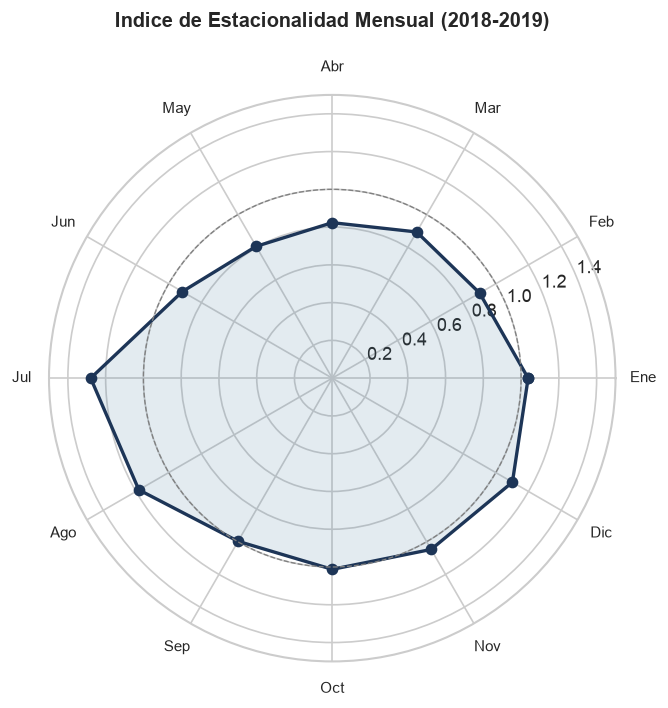

In [6]:
pre_covid = df[df['anio'].isin([2018, 2019])]
promedio_mensual = pre_covid.groupby('mes')['llegadas'].sum().reset_index()
media_global = promedio_mensual['llegadas'].mean()
promedio_mensual['indice'] = promedio_mensual['llegadas'] / media_global

meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

angulos = np.linspace(0, 2 * np.pi, 12, endpoint=False)
valores = promedio_mensual['indice'].values
valores_cerrado = np.concatenate([valores, [valores[0]]])
angulos_cerrado = np.concatenate([angulos, [angulos[0]]])

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angulos_cerrado, valores_cerrado, 'o-', color='#1d3557', lw=2, markersize=6)
ax.fill(angulos_cerrado, valores_cerrado, alpha=0.15, color='#457b9d')

ax.set_xticks(angulos)
ax.set_xticklabels(meses_nombres, fontsize=9)
ax.set_ylim(0, 1.5)
ax.axhline(1.0, color='gray', ls='--', lw=0.8)
ax.set_title('Indice de Estacionalidad Mensual (2018-2019)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 4. Llegadas acumuladas por anio (interactivo)

In [7]:
acumulado = df.groupby(['anio', 'mes'])['llegadas'].sum().reset_index()
acumulado = acumulado.sort_values(['anio', 'mes'])
acumulado['acumulado'] = acumulado.groupby('anio')['llegadas'].cumsum()
acumulado['mes_nombre'] = acumulado['mes'].map(
    dict(zip(range(1,13), ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']))
)

colores_anio = {
    2018: '#264653', 2019: '#2a9d8f', 2020: '#e63946',
    2021: '#f4a261', 2022: '#e76f51', 2023: '#606c38'
}

fig_acum = go.Figure()
for anio in sorted(acumulado['anio'].unique()):
    sub = acumulado[acumulado['anio'] == anio]
    fig_acum.add_trace(go.Scatter(
        x=sub['mes'], y=sub['acumulado'],
        mode='lines', name=str(anio),
        line=dict(color=colores_anio[anio], width=2.5 if anio in [2020, 2023] else 1.8),
        fill='tozeroy' if anio == 2020 else None,
        fillcolor='rgba(230,57,70,0.08)' if anio == 2020 else None,
        hovertemplate=f'{anio} - ' + '%{text}: %{y:,.0f}<extra></extra>',
        text=sub['mes_nombre']
    ))

fig_acum.update_layout(
    title='Llegadas Acumuladas por Anio',
    xaxis=dict(title='Mes', tickvals=list(range(1,13)),
               ticktext=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']),
    yaxis_title='Turistas acumulados',
    template='plotly_white',
    height=450,
    legend=dict(orientation='h', y=-0.15),
    font_size=11
)
fig_acum.show()

## 5. Indice de recuperacion por pais (2023 vs 2019)

In [8]:
base_2019 = df[df['anio'] == 2019].groupby('pais')['llegadas'].sum()
actual_2023 = df[df['anio'] == 2023].groupby('pais')['llegadas'].sum()
recuperacion = (actual_2023 / base_2019 * 100).round(1).sort_values(ascending=True)

colores_rec = ['#e63946' if v < 70 else '#f4a261' if v < 90 else '#2a9d8f'
               for v in recuperacion.values]

fig_rec = go.Figure(go.Bar(
    y=recuperacion.index,
    x=recuperacion.values,
    orientation='h',
    marker_color=colores_rec,
    text=[f'{v:.0f}%' for v in recuperacion.values],
    textposition='outside',
    hovertemplate='%{y}: %{x:.1f}% de niveles 2019<extra></extra>'
))

fig_rec.add_vline(x=100, line_dash='dot', line_color='gray',
                  annotation_text='Nivel 2019', annotation_position='top')

fig_rec.update_layout(
    title='Indice de Recuperacion Turistica por Pais (2023 vs 2019)',
    xaxis_title='% respecto a 2019',
    template='plotly_white',
    height=400,
    margin=dict(l=120, t=60),
    font_size=11
)
fig_rec.show()

## Observaciones

- El turismo cayo 81% en 2020. Abril-mayo fueron los meses mas criticos con menos de 5% del flujo normal.
- Chile mantiene liderazgo como mercado emisor y su recuperacion post-COVID fue la mas rapida.
- La estacionalidad muestra picos en julio-agosto (temporada alta) y diciembre.
- Al 2023 el turismo alcanzo aproximadamente 76% de los niveles pre-pandemia.